# ARIM情報活用講座：　ケモインフォマテックス応用編　
# 第3回：　水溶解度データによる機械学習モデル

## 対象読者・前提知識・動作環境・版とライセンス

**対象読者**：ARIMデータポータル会員の研究者・技術者を想定しています。Pythonの基礎文法は理解しているものとしますが、RDKit・scikit-learnに触れるのは初めてでも読み進められるように構成しています。統計学・機械学習の予備知識は前提としません。

**前提知識**：Python基礎文法、および1_Descriptor.ipynbで扱ったRDKit記述子・フィンガープリントの基礎（本編はその続編です）。

**動作環境**：Google Colab、または以下のバージョンで動作確認を行いました。

| ライブラリ | バージョン |
| --- | --- |
| Python | 3.10 |
| rdkit | 2026.03.4 |
| scikit-learn | 1.7.2 |
| pandas / numpy | 2.3.3 / 1.26.4 |

**版とライセンス**：底本は船津 公人、柴山 翔二郎『実践 マテリアルズインフォマティクス　Pythonによる材料設計のための機械学習』（近代科学社、2020）第9章第3節。データセットの出典は本編内で明記します。本ノートブックはARIMデータポータルセミナー・ワークショップ教材として配布します。

※ 本ノートブックは`cheminfo`パッケージ（`ARIM-Academy/Advanced_Tutorial_4`リポジトリに同梱）に依存しています。ローカル実行の際は`git clone`を実行してこのパッケージを取得してください。


## 底本
船津 公人、柴山 翔二郎 **『実践 マテリアルズインフォマティクス　Pythonによる材料設計のための機械学習』**、近代科学社、2020  
第９章第３節　プロジェクトの例/ 解析例２：水溶解度データと構造生成

## 本編の目標
本編では、分子フィンガープリントから候補材料を見つけます。
* 分子フィンガープリントを説明変数とした機械学習モデル（線形重回帰、部分最小二乗回帰、ランダムフォレスト回帰）について機械学習モデルを作成し、代表的なメトリクスでモデル評価をします。
* まず「2.機械学習モデル」でMLR・PLS・RFをデフォルト設定のまま比較し、そのあと「PLSによる最適な記述子の探索」の節で、Morganフィンガープリント（半径・ビット数）およびRDKit記述子についてグリッドサーチでハイパーパラメータ調整を行い、予測性の高いモデルを定めます。

## データセット
delaney-processed.csvは1128化合物の水溶解度についてのデータセットです。このデータセットは、Delaneyの論文『ESOL: Estimating Aqueous Solubility Directly from Molecular Structure』[1] で発表されたものに基づいています。

[1] John S. Delaney, "ESOL:  Estimating Aqueous Solubility Directly from Molecular Structure", J. Chem. Inf. Comput. Sci. 44, 1000–1005 (2004) (DOI: 10.1021/ci034243x)  

Delaney-processed.csvは、分子の化学式、SMILES表記、および水溶解度（log S、mol/L単位の対数値）の実測値・予測値が含まれており、これらの特性は薬物探索や環境影響評価などの目的で使用されています。

《注意》水溶解度（log S）とオクタノール水分配係数（log P）は異なる物性値です。このデータセットにはlog P列は含まれていません。


1. Compound ID	：化合物ID
1. ESOL predicted log solubility in mols per litre　：log水溶解度の予測値（ESOLモデルによる推定値）	
1. Minimum Degree：　最小次数	
1. Molecular Weight：分子量	
1. Number of H-Bond Donors	：　水素結合に関与するDonor数
1. Number of Rings	：分子内の全環数（芳香環・脂肪族環を問わない）	
1. Number of Rotatable Bonds　：　回転可能結合数	
1. Polar Surface Area　：　極性表面積	
1. measured log solubility in mols per litre：log水溶解度の実測値	
1. smiles：SMILES表記

# Google Colabにおける環境設定
google colab環境でなければ実行不要

In [ ]:
!!pip install rdkit
! pip install matplotlib_fontja
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_3_Chemoinformatics.git
%cd Advanced_Tutorial_3_Chemoinformatics

## 1.分子構造データの読み込み （P.130）
### ライブラリのインポート

In [1]:
#データ構造化ライブラリ
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt 

#記述子ライブラリ
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.AllChem import GetHashedMorganFingerprint

#機械学習
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

from warnings import filterwarnings
filterwarnings('ignore')# 警告を無視

### サンプルファイルの読み込み
1_Descriptor.ipynbと同じく「data/dataset」フォルダーにあるdelaney-processed.csvをpandasの`read_csv()`で読み込みます。RDKitの`MolFromSmiles`関数を[smiles]列に適用してmol構造への変換オブジェクトを[mol]列とする流れも同様です。

In [4]:
df=pd.read_csv('./data/dataset/delaney-processed.csv')
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
df

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,mol
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.770,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,<rdkit.Chem.rdchem.Mol object at 0x0000026B48C...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.300,Cc1occc1C(=O)Nc2ccccc2,<rdkit.Chem.rdchem.Mol object at 0x0000026B48C...
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.060,CC(C)=CCCC(C)=CC(=O),<rdkit.Chem.rdchem.Mol object at 0x0000026B48C...
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.870,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,<rdkit.Chem.rdchem.Mol object at 0x0000026B48C...
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.330,c1ccsc1,<rdkit.Chem.rdchem.Mol object at 0x0000026B48C...
...,...,...,...,...,...,...,...,...,...,...,...
1123,halothane,-2.608,1,197.381,0,0,0,0.00,-1.710,FC(F)(F)C(Cl)Br,<rdkit.Chem.rdchem.Mol object at 0x0000026B48C...
1124,Oxamyl,-0.908,1,219.266,1,0,1,71.00,0.106,CNC(=O)ON=C(SC)C(=O)N(C)C,<rdkit.Chem.rdchem.Mol object at 0x0000026B48C...
1125,Thiometon,-3.323,1,246.359,0,0,7,18.46,-3.091,CCSCCSP(=S)(OC)OC,<rdkit.Chem.rdchem.Mol object at 0x0000026B48C...
1126,2-Methylbutane,-2.245,1,72.151,0,0,1,0.00,-3.180,CCC(C)C,<rdkit.Chem.rdchem.Mol object at 0x0000026B48C...


### 説明変数(X)　SMILESからのハッシュ化
1128の化合物のSMILES構造からMolオブジェクトを生成します。具体的には、['smiles']列に`MolFromSmiles`メソッドを適用し、新たに生成されたMolオブジェクトを底本オリジナルの`cheminfo`モジュールに含まれる`HashedMorgan`クラスで処理を進めます。ここでは半径2、ビット数256で行われます。

`HashedMorgan`は、1_Descriptor.ipynbで扱った`GetMorganGenerator`（各ビットが0/1の有無を表す、ビット版のMorganフィンガープリント）とは異なり、各ビットに部分構造の**出現回数**を格納したカウント版のMorganフィンガープリントを返します。

In [5]:
from cheminfo.descriptors import HashedMorgan

hm = HashedMorgan(256,2)
X = hm.fit_transform(df['mol'])
X

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(1128, 256))

In [6]:
X.shape

(1128, 256)

### 目的変数(Y)
目的変数を'measured log solubility in mols per litre'にセットします。

In [7]:
y = df['measured log solubility in mols per litre']
y

0      -0.770
1      -3.300
2      -2.060
3      -7.870
4      -1.330
        ...  
1123   -1.710
1124    0.106
1125   -3.091
1126   -3.180
1127   -4.522
Name: measured log solubility in mols per litre, Length: 1128, dtype: float64

## 2.　機械学習モデル
ここでは、機械学習モデリングは線形重線形回帰 (MLR) 、部分最小二乗回帰（PLS）、ランダムフォレスト（RF）の３つのアルゴリズムで検討してみます。

### データセットの分割（Data set splitting）
分割は`test_size=0.2`として訓練データ：0.8、テストデータ：0.2とします。

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=.20,
                                                    random_state=42
                                                   )

### 2-1.線形重回帰 (MLR) 

In [9]:
model =  LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](256,)","[-0.07,-0.28, 0.01,...,-0.13,-0.34,-0.07]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1613
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,256
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(256)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](256,)","[133.62, 97.96, 81.09,..., 2.37, 2.31, 2.01]"


### 予測値

In [10]:
#predicts the X_train
Y_pred_train_mlr = model.predict(X_train)

#predicts the X_test
Y_pred_test_mlr = model.predict(X_test)

### MSE

In [11]:
#predicts the X_train
mse_train_mlr = mean_squared_error(Y_train, Y_pred_train_mlr)
print('平均二乗誤差 (MSE): {:.3f}'.format(mse_train_mlr))

平均二乗誤差 (MSE): 0.489


In [12]:
#predicts the X_test
mse_test_mlr = mean_squared_error(Y_test, Y_pred_test_mlr)
print('平均二乗誤差 (MSE): {:.3f}'.format(mse_test_mlr))

平均二乗誤差 (MSE): 1.238


### R2スコア

In [13]:
#predicts the X_train
r2_train_mlr = r2_score(Y_train, Y_pred_train_mlr)
print('決定係数 (R^2): {:.3f}'.format(r2_train_mlr))

決定係数 (R^2): 0.886


In [14]:
#predicts the X_test
r2_test_mlr = r2_score(Y_test, Y_pred_test_mlr)
print('決定係数 (R^2): {:.3f}'.format(r2_test_mlr))

決定係数 (R^2): 0.738


### MAE

In [15]:
#predicts the X_train
mae_train_mlr = mean_absolute_error(Y_train, Y_pred_train_mlr)
print('平均絶対誤差（MAE） : {:.3f}'.format(mae_train_mlr))

平均絶対誤差（MAE） : 0.550


In [16]:
#predicts the X_test
mae_test_mlr = mean_absolute_error(Y_test, Y_pred_test_mlr)
print('平均絶対誤差（MAE） : {:.3f}'.format(mae_test_mlr))

平均絶対誤差（MAE） : 0.858


### RMSE

In [17]:
#predicts the X_train
rmse_train_mlr = root_mean_squared_error(Y_train, Y_pred_train_mlr)
print('二乗平均平方誤差(RMSE) : {:.3f}'.format(rmse_train_mlr))

二乗平均平方誤差(RMSE) : 0.699


In [19]:
#predicts the X_test
rmse_test_mlr = root_mean_squared_error(Y_test, Y_pred_test_mlr)
print('二乗平均平方誤差(RMSE) : {:.3f}'.format(rmse_test_mlr))

二乗平均平方誤差(RMSE) : 1.113


### Experimental-Predict Plot

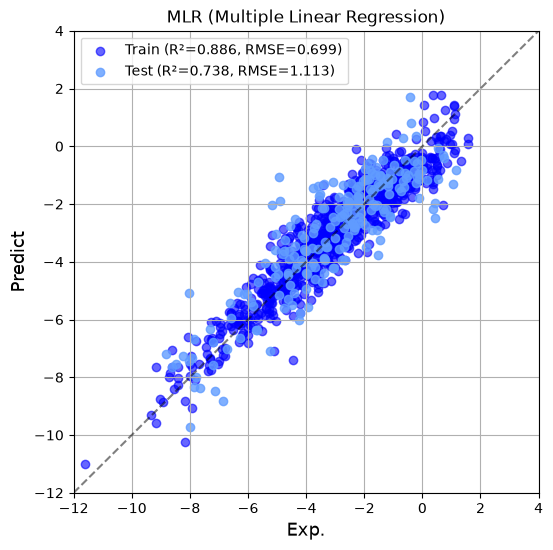

In [20]:
# 図1：線形重回帰（MLR）のExperimental-Predictプロット
plt.figure(figsize=(6,6))

plt.scatter(x=Y_train, y=Y_pred_train_mlr, c="blue", alpha=0.6, label=f'Train (R²={r2_train_mlr:.3f}, RMSE={rmse_train_mlr:.3f})')
plt.scatter(x=Y_test, y=Y_pred_test_mlr, c="#619CFF", alpha=0.8, label=f'Test (R²={r2_test_mlr:.3f}, RMSE={rmse_test_mlr:.3f})')

# 理想的な予測（y=x）を示す対角線
ideal_line = np.linspace(-12, 4, 100)
plt.plot(ideal_line, ideal_line, color="black", linestyle="--", alpha=0.5)

plt.xlabel('Exp.', fontsize=13)
plt.ylabel('Predict', fontsize=13)
plt.xlim(-12,4)
plt.ylim(-12,4)
plt.grid()
plt.legend(fontsize=10, loc='upper left')
plt.title('MLR (Multiple Linear Regression)')

plt.show()


### 2-2.部分最小二乗回帰（PLS）

In [21]:
model =  PLSRegression()
model.fit(X_train, Y_train)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",2
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True
Name,Type,Value
"coef_ coef_: ndarray of shape (n_target, n_features)The coefficients of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`.","ndarray[float64](1, 256)","[[ 0.08,-0.03,-0.07,..., 0.1 ,-0.08, 0.08]]"
"intercept_ intercept_: ndarray of shape (n_targets,)The intercepts of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`... versionadded:: 1.1","ndarray[float64](1,)",[-3.04]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,256
"n_iter_ n_iter_: list of shape (n_components,)Number of iterations of the power method, for eachcomponent.",list,"[1, 1]"
"x_loadings_ x_loadings_: ndarray of shape (n_features, n_components)The loadings of `X`.","ndarray[float64](256, 2)","[[ 0.03,-0.08], [-0.03, 0.01], [-0.02, 0.02], ..., [ 0.02,-0.02], [-0.01,-0.01], [ 0.04,-0.1 ]]"


### 予測値

In [22]:
#predicts the X_train
Y_pred_train_pls = model.predict(X_train)

#predicts the X_test
Y_pred_test_pls = model.predict(X_test)

### MSE

In [23]:
#predicts the X_train
mse_train_pls = mean_squared_error(Y_train, Y_pred_train_pls)
print('平均二乗誤差 (MSE): {:.3f}'.format(mse_train_pls))

平均二乗誤差 (MSE): 1.091


In [24]:
#predicts the X_test
mse_test_pls = mean_squared_error(Y_test, Y_pred_test_pls)
print('平均二乗誤差 (MSE): {:.3f}'.format(mse_test_pls))

平均二乗誤差 (MSE): 1.332


### R2スコア

In [25]:
#predicts the X_train
r2_train_pls = r2_score(Y_train, Y_pred_train_pls)
print('決定係数 (R^2): {:.3f}'.format(r2_train_pls))

決定係数 (R^2): 0.747


In [26]:
#predicts the X_test
r2_test_pls = r2_score(Y_test, Y_pred_test_pls)
print('決定係数 (R^2): {:.3f}'.format(r2_test_pls))

決定係数 (R^2): 0.718


### MAE

In [27]:
#predicts the X_train
mae_train_pls = mean_absolute_error(Y_train, Y_pred_train_pls)
print('平均絶対誤差（MAE） : {:.3f}'.format(mae_train_pls))

平均絶対誤差（MAE） : 0.820


In [28]:
#predicts the X_test
mae_test_pls = mean_absolute_error(Y_test, Y_pred_test_pls)
print('平均絶対誤差（MAE） : {:.3f}'.format(mae_test_pls))

平均絶対誤差（MAE） : 0.899


### RMSE

In [29]:
#predicts the X_train
rmse_train_pls = root_mean_squared_error(Y_train, Y_pred_train_pls)
print('二乗平均平方誤差(RMSE) : {:.3f}'.format(rmse_train_pls))

二乗平均平方誤差(RMSE) : 1.045


In [30]:
#predicts the X_test
rmse_test_pls = root_mean_squared_error(Y_test, Y_pred_test_pls)
print('二乗平均平方誤差(RMSE) : {:.3f}'.format(rmse_test_pls))

二乗平均平方誤差(RMSE) : 1.154


### Experimental-Predict Plot

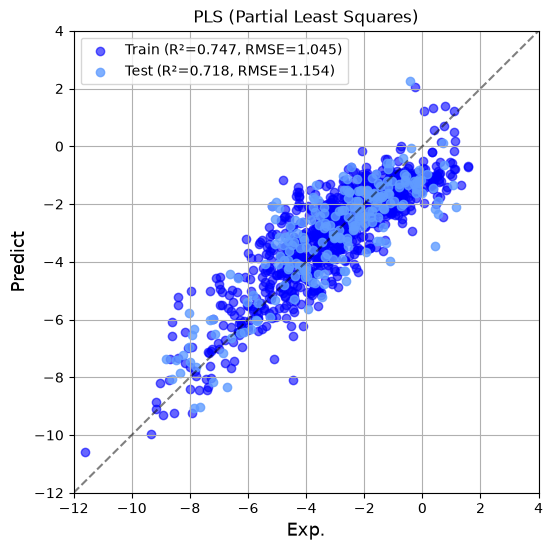

In [31]:
# 図2：部分最小二乗回帰（PLS）のExperimental-Predictプロット
plt.figure(figsize=(6,6))

plt.scatter(x=Y_train, y=Y_pred_train_pls, c="blue", alpha=0.6, label=f'Train (R²={r2_train_pls:.3f}, RMSE={rmse_train_pls:.3f})')
plt.scatter(x=Y_test, y=Y_pred_test_pls, c="#619CFF", alpha=0.8, label=f'Test (R²={r2_test_pls:.3f}, RMSE={rmse_test_pls:.3f})')

ideal_line = np.linspace(-12, 4, 100)
plt.plot(ideal_line, ideal_line, color="black", linestyle="--", alpha=0.5)

plt.xlabel('Exp.', fontsize=13)
plt.ylabel('Predict', fontsize=13)
plt.xlim(-12,4)
plt.ylim(-12,4)
plt.grid()
plt.legend(fontsize=10, loc='upper left')
plt.title('PLS (Partial Least Squares)')

plt.show()


### 2-3.ランダムフォレスト回帰（RFR）

In [32]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### 予測値

In [33]:
#predicts the X_train
Y_pred_train_rf = model.predict(X_train)

#predicts the X_test
Y_pred_test_rf = model.predict(X_test)

### MSE

In [34]:
#predicts the X_train
mse_train_rf = mean_squared_error(Y_train, Y_pred_train_rf)
print('平均二乗誤差 (MSE): {:.3f}'.format(mse_train_rf))

平均二乗誤差 (MSE): 0.136


In [35]:
#predicts the X_test
mse_test_rf = mean_squared_error(Y_test, Y_pred_test_rf)
print('平均二乗誤差 (MSE): {:.3f}'.format(mse_test_rf))

平均二乗誤差 (MSE): 0.868


### R2スコア

In [36]:
#predicts the X_train
r2_train_rf = r2_score(Y_train, Y_pred_train_rf)
print('決定係数 (R^2): {:.3f}'.format(r2_train_rf))

決定係数 (R^2): 0.969


In [37]:
#predicts the X_test
r2_test_rf = r2_score(Y_test, Y_pred_test_rf)
print('決定係数 (R^2): {:.3f}'.format(r2_test_rf))

決定係数 (R^2): 0.816


### MAE

In [38]:
#predicts the X_train
mae_train_rf = mean_absolute_error(Y_train, Y_pred_train_rf)
print('平均絶対誤差（MAE） : {:.3f}'.format(mae_train_rf))

平均絶対誤差（MAE） : 0.279


In [39]:
#predicts the X_test
mae_test_rf = mean_absolute_error(Y_test, Y_pred_test_rf)
print('平均絶対誤差（MAE） : {:.3f}'.format(mae_test_rf))

平均絶対誤差（MAE） : 0.690


### RMSE

In [40]:
#predicts the X_train
rmse_train_rf = root_mean_squared_error(Y_train, Y_pred_train_rf)
print('二乗平均平方誤差(RMSE) : {:.3f}'.format(rmse_train_rf))

二乗平均平方誤差(RMSE) : 0.368


In [41]:
#predicts the X_test
rmse_test_rf = root_mean_squared_error(Y_test, Y_pred_test_rf)
print('二乗平均平方誤差(RMSE) : {:.3f}'.format(rmse_test_rf))

二乗平均平方誤差(RMSE) : 0.932


### Experimental-Predict Plot

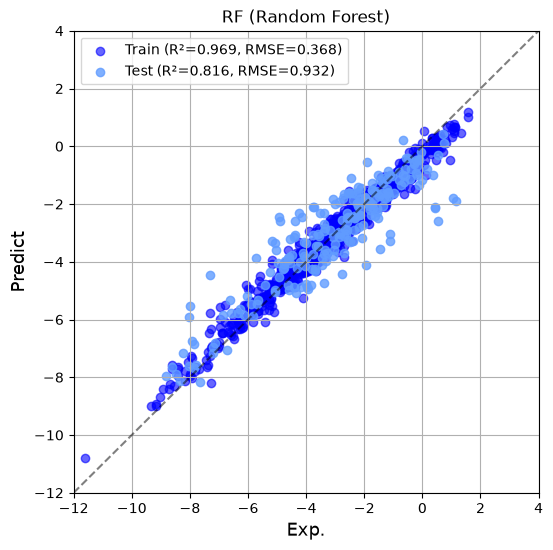

In [42]:
# 図3：ランダムフォレスト回帰（RF）のExperimental-Predictプロット
plt.figure(figsize=(6,6))

plt.scatter(x=Y_train, y=Y_pred_train_rf, c="blue", alpha=0.6, label=f'Train (R²={r2_train_rf:.3f}, RMSE={rmse_train_rf:.3f})')
plt.scatter(x=Y_test, y=Y_pred_test_rf, c="#619CFF", alpha=0.8, label=f'Test (R²={r2_test_rf:.3f}, RMSE={rmse_test_rf:.3f})')

ideal_line = np.linspace(-12, 4, 100)
plt.plot(ideal_line, ideal_line, color="black", linestyle="--", alpha=0.5)

plt.xlabel('Exp.', fontsize=13)
plt.ylabel('Predict', fontsize=13)
plt.xlim(-12,4)
plt.ylim(-12,4)
plt.grid()
plt.legend(fontsize=10, loc='upper left')
plt.title('RF (Random Forest)')

plt.show()


## ①3つの回帰モデルの比較

線形重回帰（MLR）、部分最小二乗回帰（PLS）、ランダムフォレスト回帰（RF）の3モデルについて、訓練データ・テストデータそれぞれの評価指標を並べて比較します。


In [43]:
# ①MLR・PLS・RFの評価指標を横並びで比較する
comparison = pd.DataFrame({
    'モデル': ['MLR', 'PLS', 'RF'],
    'R2 (train)': [r2_train_mlr, r2_train_pls, r2_train_rf],
    'R2 (test)': [r2_test_mlr, r2_test_pls, r2_test_rf],
    'RMSE (train)': [rmse_train_mlr, rmse_train_pls, rmse_train_rf],
    'RMSE (test)': [rmse_test_mlr, rmse_test_pls, rmse_test_rf],
    'MAE (train)': [mae_train_mlr, mae_train_pls, mae_train_rf],
    'MAE (test)': [mae_test_mlr, mae_test_pls, mae_test_rf],
})
comparison

,モデル,R2 (train),R2 (test),RMSE (train),RMSE (test),MAE (train),MAE (test)
0,MLR,0.886397,0.738080,0.699485,1.112675,0.550472,0.857842
1,PLS,0.746626,0.718263,1.044638,1.153999,0.819857,0.899218
2,RF,0.968534,0.816350,0.368133,0.931705,0.278949,0.689977


## PLSによる最適な記述子の探索（P.131）
MorganフィンガープリントおよびRDKit記述子を特徴量とする２ケースについて検討します。

### (1) Morganフィンガープリントの場合

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

In [45]:
df_train, df_test = train_test_split(df, 
                                     test_size=.20, 
                                     random_state=42)

In [46]:
TARGET=['measured log solubility in mols per litre']
ytrain = df_train[TARGET]
ytrain

,measured log solubility in mols per litre
876,-1.400
712,-0.390
554,-4.400
688,-2.676
780,-8.000
...,...
121,-4.800
1044,-2.120
1095,-3.620
860,-0.460


In [47]:
params={'n_components': np.arange(1,16)}
scores = np.zeros((18,3))
count = 0

for radius in range(1, 4):
    for n_bits in 2**np.arange(5, 11):
        model = GridSearchCV(PLSRegression(), params, cv=5)
        Xtrain = HashedMorgan(n_bits, radius).fit_transform(df_train['mol'])

        model.fit(Xtrain, ytrain)
        
        score_cv = model.best_score_
        scores[count,:] = np.array([radius, n_bits, score_cv])
        count+=1 

### スコアの表示
交差検定の結果を表示します。横軸に半径、縦軸にはビット数としてR2スコアを色別して表示します。

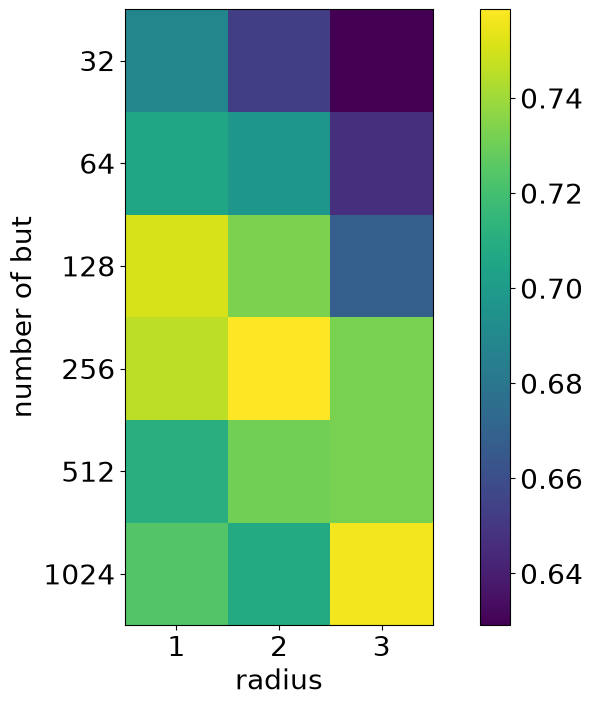

In [48]:
# 図4：Morganフィンガープリントの半径・ビット数に対するPLS交差検証R2スコアのヒートマップ
mpl.rcParams['figure.figsize'] = [12, 8]
mpl.rcParams['font.size'] = 20

fig,ax=plt.subplots()
im = ax.imshow(scores[:,-1].reshape(3,6).T)
fig.colorbar(im)

ax.set_xticks(range(3))
ax.set_yticks(range(6))
ax.set_xticklabels(range(1,4))
ax.set_yticklabels(map(int,scores[:6,1]))

plt.xlabel('radius')
plt.ylabel('number of but')
#plt.savefig('./results/10.3-optim-hashedmorgan-pls.jpg')

plt.show()

### 最良のパラメータを確認
グリッドサーチによる最良のパラメーターは半径２、ビット数256のときにR2スコアとして0.76が得られました。

In [49]:
ix=scores[:,-1].argmax()
print('radius: {}, n_bits: {} R^2:{:.3f}'.format(*scores[ix,:]))

radius: 2.0, n_bits: 256.0 R^2:0.759


### (2) RDKit記述子の場合(P.132)
同様にしてRDKit記述子についても機械学習モデルを生成してみましょう。

In [50]:
from cheminfo.descriptors import RDKitDescriptor

rdcalc = RDKitDescriptor()

X = rdcalc.fit_transform(df_train['mol'])
Xtrain = np.array(X.tolist())

X2 = rdcalc.transform(df_test['mol'])
Xtest = np.array(X2.tolist())

In [51]:
ytest = df_test[TARGET]

In [52]:
params = {'n_components': np.arange(1, 16)}
optim = GridSearchCV(PLSRegression(), params)

In [53]:
optim.fit(Xtrain, ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",PLSRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_components': array([ 1, 2..., 13, 14, 15])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting,

### 予測値

In [54]:
ycalc = optim.predict(Xtrain)
ypred = optim.predict(Xtest)

### 評価値（R2スコア）

In [55]:
r2_train_rdkit_pls = metrics.r2_score(ytrain, ycalc)
r2_cv_rdkit_pls = optim.best_score_
r2_test_rdkit_pls = metrics.r2_score(ytest, ypred)

print('訓練データ R^2:      %.3f' % r2_train_rdkit_pls)
print('交差検証(CV) R^2:    %.3f' % r2_cv_rdkit_pls)
print('テストデータ R^2:    %.3f' % r2_test_rdkit_pls)

訓練データ R^2:      0.924
交差検証(CV) R^2:    0.886
テストデータ R^2:    0.894


RDKit記述子の場合は訓練データでR2スコアが0.92、交差検証・テストデータのいずれも0.89前後と、Morganフィンガープリントのみを使った場合（R2≈0.76）よりも高い精度になっています。分子量・TPSAなどの物性値を直接含むRDKit記述子の情報量の多さが効いていると考えられます。

### Experimental-Predict Plot
RDKitのExperimental-Predictプロット（Exp-Predictプロット）を描画します。

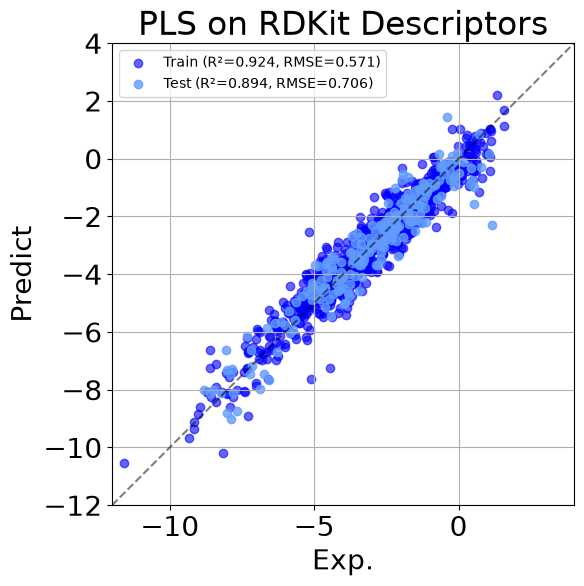

In [56]:
# 図5：RDKit記述子によるPLS回帰のExperimental-Predictプロット
rmse_train_rdkit_pls = root_mean_squared_error(ytrain, ycalc)
rmse_test_rdkit_pls = root_mean_squared_error(ytest, ypred)

plt.figure(figsize=(6,6))

plt.scatter(ytrain, ycalc, c="blue", alpha=0.6, label=f'Train (R²={r2_train_rdkit_pls:.3f}, RMSE={rmse_train_rdkit_pls:.3f})')
plt.scatter(ytest, ypred, c="#619CFF", alpha=0.8, label=f'Test (R²={r2_test_rdkit_pls:.3f}, RMSE={rmse_test_rdkit_pls:.3f})')

ideal_line = np.linspace(-12, 4, 100)
plt.plot(ideal_line, ideal_line, color="black", linestyle="--", alpha=0.5)

plt.axis('square')
plt.xlabel('Exp.')
plt.ylabel('Predict')
plt.xlim(-12,4)
plt.ylim(-12,4)
plt.grid()
plt.legend(fontsize=10, loc='upper left')
plt.title('PLS on RDKit Descriptors')

plt.show()


### モデル保存
上記の予測モデルを保存します。ここではjoblibを使って保存します。

In [57]:
import os
os.makedirs('models', exist_ok=True)  # ローカル実行では models/ フォルダが存在しないため作成する

from joblib import dump
dump(optim, './models/9.3_rdkit_pls.joblib')

['./models/9.3_rdkit_pls.joblib']

joblibは、Pythonのパッケージであり、効率的な並列処理やデータのシリアル化（直列化）をサポートするためのツールです。主な用途は、大規模な計算やデータ処理を高速化するために使用されます。joblibは、NumPyの多次元配列や他のPythonオブジェクトをシリアル化してディスクに保存し、後で再ロードすることで、再計算を回避することができます。

joblibの主な特徴は次のとおりです：

1. 並列処理のサポート：joblibは、マルチコアプロセッサを活用して並列計算を行うことができます。これにより、CPUの複数コアを使用して計算を高速化することができます。特に、大量のデータを処理する際に有効です。

2. メモリ効率の向上：joblibは、メモリ使用量を最小限に抑えるために、効率的なメモリマッピングを使用します。これにより、大規模なデータセットを処理する際のメモリオーバーヘッドを軽減できます。

3. シンプルなAPI：joblibは、Pythonの標準ライブラリの`pickle`モジュールと似たシンプルなAPIを提供します。これにより、既存のコードを比較的簡単にjoblibに移行できます。

joblibの主なユースケースは、機械学習やデータサイエンス、大規模なデータ処理などです。特に、機械学習のモデルのトレーニングやハイパーパラメータの探索など、計算が重い処理において高い効果を発揮します。

使用例を示します：

```python
import joblib

# シリアル化（オブジェクトの保存）
data = [1, 2, 3, 4, 5]
joblib.dump(data, 'data.pkl')

# ロード（オブジェクトの読み込み）
loaded_data = joblib.load('data.pkl')
print(loaded_data)  # [1, 2, 3, 4, 5]
```

この例では、Pythonリスト`data`を`data.pkl`というファイル名で保存し、再度読み込んでいます。このようにして、データの保存と再利用が可能となります。

## 【参考】ハッシュ化されたMorganフィンガープリントを出力するクラス
船津先生のオリジナルであるMorganフィンガープリント（頻度）を取り出す`HashedMorgan`クラスを使ってヒストグラムを作成します。

In [58]:
from cheminfo.descriptors import HashedMorgan

hm = HashedMorgan()
X = hm.fit_transform(df['mol'])

In [59]:
X.shape

(1128, 512)

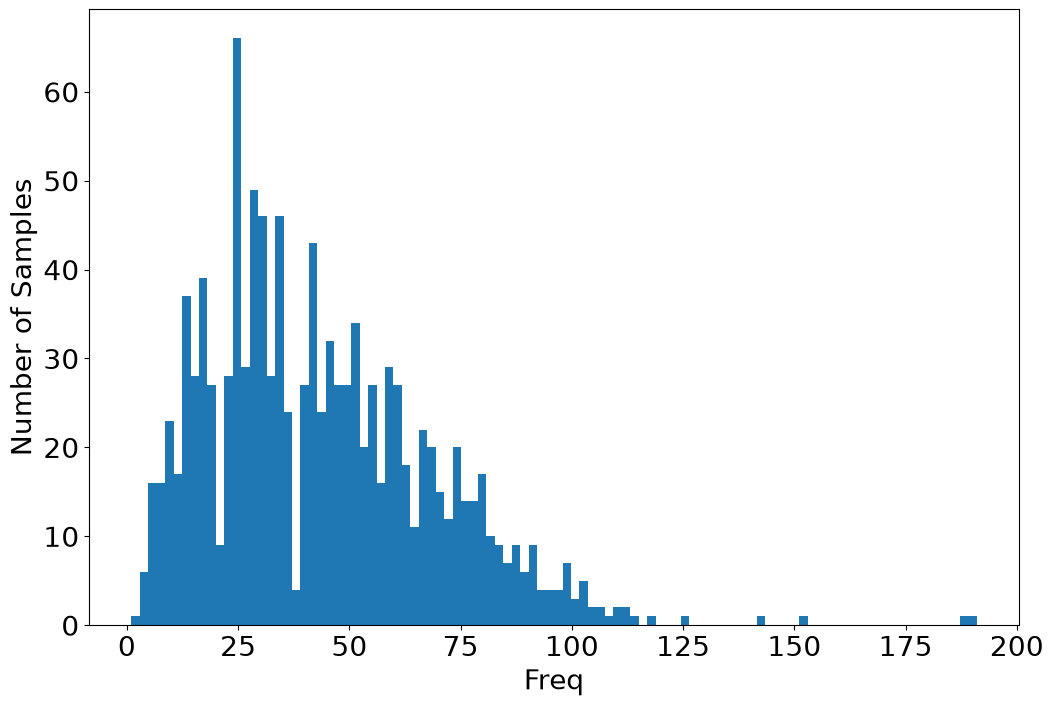

In [60]:
# 図6：HashedMorganフィンガープリント（デフォルト設定）の各化合物あたり合計出現回数の分布
plt.hist(X.sum(axis=1), bins=100)

plt.xlabel('Freq')
plt.ylabel('Number of Samples')
plt.show()

## ②まとめ

- Morganフィンガープリント（カウント版、半径3・256ビット）を説明変数として、線形重回帰（MLR）・部分最小二乗回帰（PLS）・ランダムフォレスト回帰（RF）の3モデルを比較しました（①の比較表を参照）。
- PLSについては、Morganフィンガープリントの半径・ビット数をグリッドサーチで調整し、半径2・256ビットのときに交差検証R2スコアが最も高くなることを確認しました（約0.76）。
- 特徴量をMorganフィンガープリントからRDKit記述子（分子量・TPSAなどの物性値を含む209種類前後の数値記述子）に切り替えると、PLSのR2スコアは訓練データ0.92、交差検証・テストデータともに0.89前後まで向上しました。フィンガープリント（部分構造の有無・頻度）よりも、物性値を直接含む記述子の方がこのデータセットでは予測に有効であることがわかります。
- 最終的に採用したRDKit記述子＋PLSモデルは`models/9.3_rdkit_pls.joblib`として保存し、5_Screening.ipynbで再利用します。

## ③本ノートブックで扱っていないこと（今後の課題）

- MLR・RFについてはハイパーパラメータ調整（グリッドサーチ）を行っていません。PLSと同様の探索を行うと結果が変わる可能性があります。
- 特徴量重要度の分析（RFの`feature_importances_`など）や、どの記述子が予測に効いているかの解釈は扱っていません。
- テストデータでの評価が1回のtrain_test_split（`random_state=42`）に基づくものである点に注意してください。分割を変えたときの性能のばらつきは検証していません。

## ④演習問題

1. ①の比較表を見て、MLR・PLS・RFのうちどのモデルが最もテストデータでのR2スコアが高いか確認してみましょう。また、訓練データとテストデータのR2スコアの差が最も大きいモデルはどれで、それは何を意味するか考えてみましょう。
2. `train_test_split`の`random_state`を42以外の値に変えて、RDKit記述子＋PLSモデルのテストR2スコアがどれくらい変動するか確認してみましょう。
3. `RandomForestRegressor`の`n_estimators`を100から500に増やすと、テストデータのR2スコアはどう変化するか確認してみましょう。
